In [5]:
import os
import math
import random
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../images", exist_ok=True)

ALPH = string.ascii_uppercase
ALPH_SET = set(ALPH)

In [6]:
def clean_text(s: str) -> str:
    """Plaintext/ciphertext letters only: keep A-Z."""
    s = s.upper()
    return "".join(ch for ch in s if ch in ALPH_SET)

def clean_ciphertext(s: str, indicator: str = "|") -> str:
    """Ciphertext w/ indicator: keep A-Z plus the indicator marker."""
    s = s.upper()
    keep = ALPH_SET | {indicator}
    return "".join(ch for ch in s if ch in keep)

In [7]:
def shannon_entropy_bits(s: str) -> float:
    s = clean_text(s)
    N = len(s)
    if N == 0:
        return float("nan")
    c = Counter(s)
    H = 0.0
    for n in c.values():
        p = n / N
        H -= p * math.log(p, 2)
    return H

In [8]:
def make_mono_key(rng: random.Random) -> dict:
    perm = list(ALPH)
    rng.shuffle(perm)
    return {p: c for p, c in zip(ALPH, perm)}

def mono_encrypt(plaintext: str, key: dict) -> str:
    pt = clean_text(plaintext)
    return "".join(key[ch] for ch in pt)

In [9]:
def rot_alpha(shift: int) -> str:
    shift %= 26
    return ALPH[shift:] + ALPH[:shift]

def shift_to_char(shift: int) -> str:
    return chr((shift % 26) + ord("A"))

def char_to_shift(ch: str) -> int:
    ch = ch.upper()
    if ch not in ALPH_SET:
        raise ValueError("Shift character must be A-Z")
    return ord(ch) - ord("A")

In [10]:
def alberti_encrypt_periodic(plaintext: str, period: int = 20, shifts=None, rng=None):
    pt = clean_text(plaintext)
    if not pt:
        return {"ciphertext": "", "period": period, "shifts": []}

    n = len(pt)
    blocks = (n + period - 1) // period

    if shifts is None:
        if rng is None:
            rng = random.Random()
        shifts = [rng.randrange(26) for _ in range(blocks)]
    else:
        if len(shifts) < blocks:
            raise ValueError("shifts list shorter than number of blocks")

    out = []
    for b in range(blocks):
        inner = rot_alpha(shifts[b])
        start, end = b * period, min((b + 1) * period, n)
        for ch in pt[start:end]:
            out.append(inner[ord(ch) - 65])

    return {"ciphertext": "".join(out), "period": period, "shifts": shifts[:blocks]}

In [11]:
def alberti_encrypt_with_indicator(
    plaintext: str,
    period: int = 20,
    indicator: str = "|",
    shifts=None,
    rng=None
):
    pt = clean_text(plaintext)
    if not pt:
        return {"ciphertext": "", "period": period, "shifts": [], "indicator": indicator}

    n = len(pt)
    blocks = (n + period - 1) // period

    if shifts is None:
        if rng is None:
            rng = random.Random()
        shifts = [rng.randrange(26) for _ in range(blocks)]
    else:
        if len(shifts) < blocks:
            raise ValueError("shifts list shorter than number of blocks")

    out = []
    for b in range(blocks):
        sh = shifts[b]
        inner = rot_alpha(sh)

        out.append(indicator)
        out.append(shift_to_char(sh))

        start, end = b * period, min((b + 1) * period, n)
        for ch in pt[start:end]:
            out.append(inner[ord(ch) - 65])

    return {"ciphertext": "".join(out), "period": period, "shifts": shifts[:blocks], "indicator": indicator}

In [12]:
base = (
    "Cryptography is the study of secure communication. "
    "A fixed substitution leaks frequency structure. "
    "Rotating alphabets disrupts leakage and increases uncertainty for an attacker. "
    "This notebook compares Shannon entropy under different classical cipher schemes. "
)

plaintext = base * 80
pt = clean_text(plaintext)
len(pt)

17760

In [13]:
rng = random.Random(999)
trials = 300
period_choices = [5, 10, 15, 20, 30]
indicator = "|"

H_plain = shannon_entropy_bits(pt)

H_mono = []
H_alb_noind = []
H_alb_ind = []

for _ in range(trials):
    # Mono
    key = make_mono_key(rng)
    ct_m = mono_encrypt(pt, key)
    H_mono.append(shannon_entropy_bits(ct_m))

    # Alberti (no indicator)
    period = rng.choice(period_choices)
    ct_a = alberti_encrypt_periodic(pt, period=period, rng=rng)["ciphertext"]
    H_alb_noind.append(shannon_entropy_bits(ct_a))

    # Alberti (with indicator)
    ct_i = alberti_encrypt_with_indicator(pt, period=period, indicator=indicator, rng=rng)["ciphertext"]
    ct_i_letters = ct_i.replace(indicator, "")
    H_alb_ind.append(shannon_entropy_bits(ct_i_letters))

df = pd.DataFrame({
    "Plaintext": [H_plain] * trials,
    "Monoalphabetic": H_mono,
    "Alberti (no indicator)": H_alb_noind,
    "Alberti (with indicator)": H_alb_ind
})

df.describe()

,Plaintext,Monoalphabetic,Alberti (no indicator),Alberti (with indicator)
count,300.000000,300.000000,300.000000,300.000000
mean,4.107975,4.107975,4.699203,4.699204
std,0.000000,0.000000,0.000434,0.000437
min,4.107975,4.107975,4.697441,4.696920
25%,4.107975,4.107975,4.698981,4.698960
50%,4.107975,4.107975,4.699269,4.699260
75%,4.107975,4.107975,4.699496,4.699489
max,4.107975,4.107975,4.700091,4.699987


In [14]:
df.agg(["mean", "std"])

,Plaintext,Monoalphabetic,Alberti (no indicator),Alberti (with indicator)
mean,4.107975,4.107975,4.699203,4.699204
std,0.000000,0.000000,0.000434,0.000437


C:\Users\belgr\AppData\Local\Temp\ipykernel_139620\3318775686.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


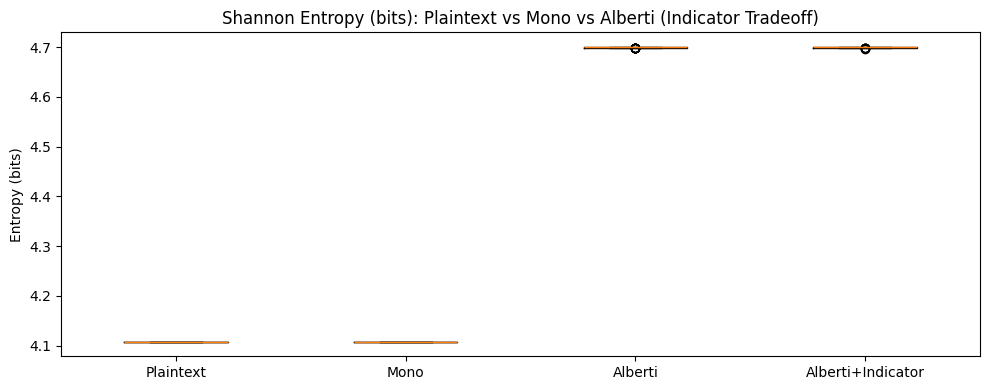

Saved: ../images/entropy_box_indicator_tradeoff.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.boxplot(
    [df["Plaintext"], df["Monoalphabetic"], df["Alberti (no indicator)"], df["Alberti (with indicator)"]],
    labels=["Plaintext", "Mono", "Alberti", "Alberti+Indicator"]
)

ax.set_title("Shannon Entropy (bits): Plaintext vs Mono vs Alberti (Indicator Tradeoff)")
ax.set_ylabel("Entropy (bits)")

plt.tight_layout()
fig.savefig("../images/entropy_box_indicator_tradeoff.png", dpi=160)
plt.show()

print("Saved: ../images/entropy_box_indicator_tradeoff.png")

In [16]:
print("Plaintext entropy (bits):", H_plain)
print("Theoretical max for uniform A-Z:", math.log(26, 2))

Plaintext entropy (bits): 4.10797505838597
Theoretical max for uniform A-Z: 4.700439718141093
